In [1]:
import pandas as pd

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

classiDataset = ['GSE41848', 'GSE41849', 'GSE146383', 'GSE13732', 'GSE136411', 'GSE17048', 'GSE41890', 'GSE21942']

# Load your data
microarray_pre = pd.read_csv("../Dataset/microarray/MergedDatasetFull_symbol.csv")
microarray_post = pd.read_csv("../Dataset/microarray/MergedDatasetFullCombat_symbol.csv")

# --- Function to process and plot PCA for a given DataFrame ---
def plot_pca(data, title_suffix, ax, scaler_type='StandardScaler'):
    """
    Performs PCA and plots the results for a given DataFrame.

    Args:
        data (pd.DataFrame): The input DataFrame containing 'SampleID', 'Label', and features.
        title_suffix (str): Suffix for the plot title (e.g., '(Pre-Combat)').
        ax (matplotlib.axes.Axes): The axes object to draw the plot on.
        scaler_type (str): Type of scaler to use. Options: 'StandardScaler',
                           'MinMaxScaler', 'RobustScaler', or None (no scaling).
                           Defaults to 'StandardScaler'.
    """
    data_for_pca = data.copy()

    sample_ids = data_for_pca['SampleID']
    features = data_for_pca.drop(columns=['SampleID', 'Label'])

    # Apply selected scaler
    if scaler_type == 'StandardScaler':
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)
        print(f"Applied StandardScaler for {title_suffix}")
    elif scaler_type == 'MinMaxScaler':
        scaler = MinMaxScaler()
        scaled_features = scaler.fit_transform(features)
        print(f"Applied MinMaxScaler for {title_suffix}")
    elif scaler_type == 'RobustScaler':
        scaler = RobustScaler()
        scaled_features = scaler.fit_transform(features)
        print(f"Applied RobustScaler for {title_suffix}")
    elif scaler_type is None:
        scaled_features = features.values # Use raw values if no scaling
        print(f"No scaling applied for {title_suffix}")
    else:
        raise ValueError("Invalid scaler_type. Choose from 'StandardScaler', 'MinMaxScaler', 'RobustScaler', or None.")

    pca = PCA(n_components=2, random_state=42)
    principal_components = pca.fit_transform(scaled_features)

    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    group_variable = sample_ids.str.split('-').str[0]
    pca_df['Group'] = group_variable.apply(lambda x: classiDataset[int(x)])

    sns.scatterplot(
        x='PC1',
        y='PC2',
        hue='Group',
        data=pca_df,
        palette='viridis',
        s=20,
        alpha=0.8,
        ax=ax
    )
    ax.set_title(f'PCA of Microarray Data {title_suffix}\n(Scaler: {scaler_type or "None"})')
    ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    ax.legend(title='Sample Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)


# --- Create a figure with two subplots side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Increased figsize for better readability with scaler info

# Example usage with different scalers:

# Option 1: Using StandardScaler (default)
plot_pca(microarray_pre, '(Pre-Combat)', axes[0], scaler_type='StandardScaler')
#plot_pca(microarray_post, '(Post-Combat)', axes[1], scaler_type='StandardScaler')

# Option 2: Using MinMaxScaler (uncomment and run to see this version)
# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# plot_pca(microarray_pre, '(Pre-Combat)', axes[0], scaler_type='MinMaxScaler')
plot_pca(microarray_post, '(Post-Combat)', axes[1], scaler_type='MinMaxScaler')

# Option 3: Using RobustScaler (uncomment and run to see this version)
# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# plot_pca(microarray_pre, '(Pre-Combat)', axes[0], scaler_type='RobustScaler')
# plot_pca(microarray_post, '(Post-Combat)', axes[1], scaler_type='RobustScaler')

# Option 4: No scaling (uncomment and run to see this version)
# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# plot_pca(microarray_pre, '(Pre-Combat)', axes[0], scaler_type=None)
# plot_pca(microarray_post, '(Post-Combat)', axes[1], scaler_type=None)


plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 92273 × 19061
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 54525 × 18725
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts

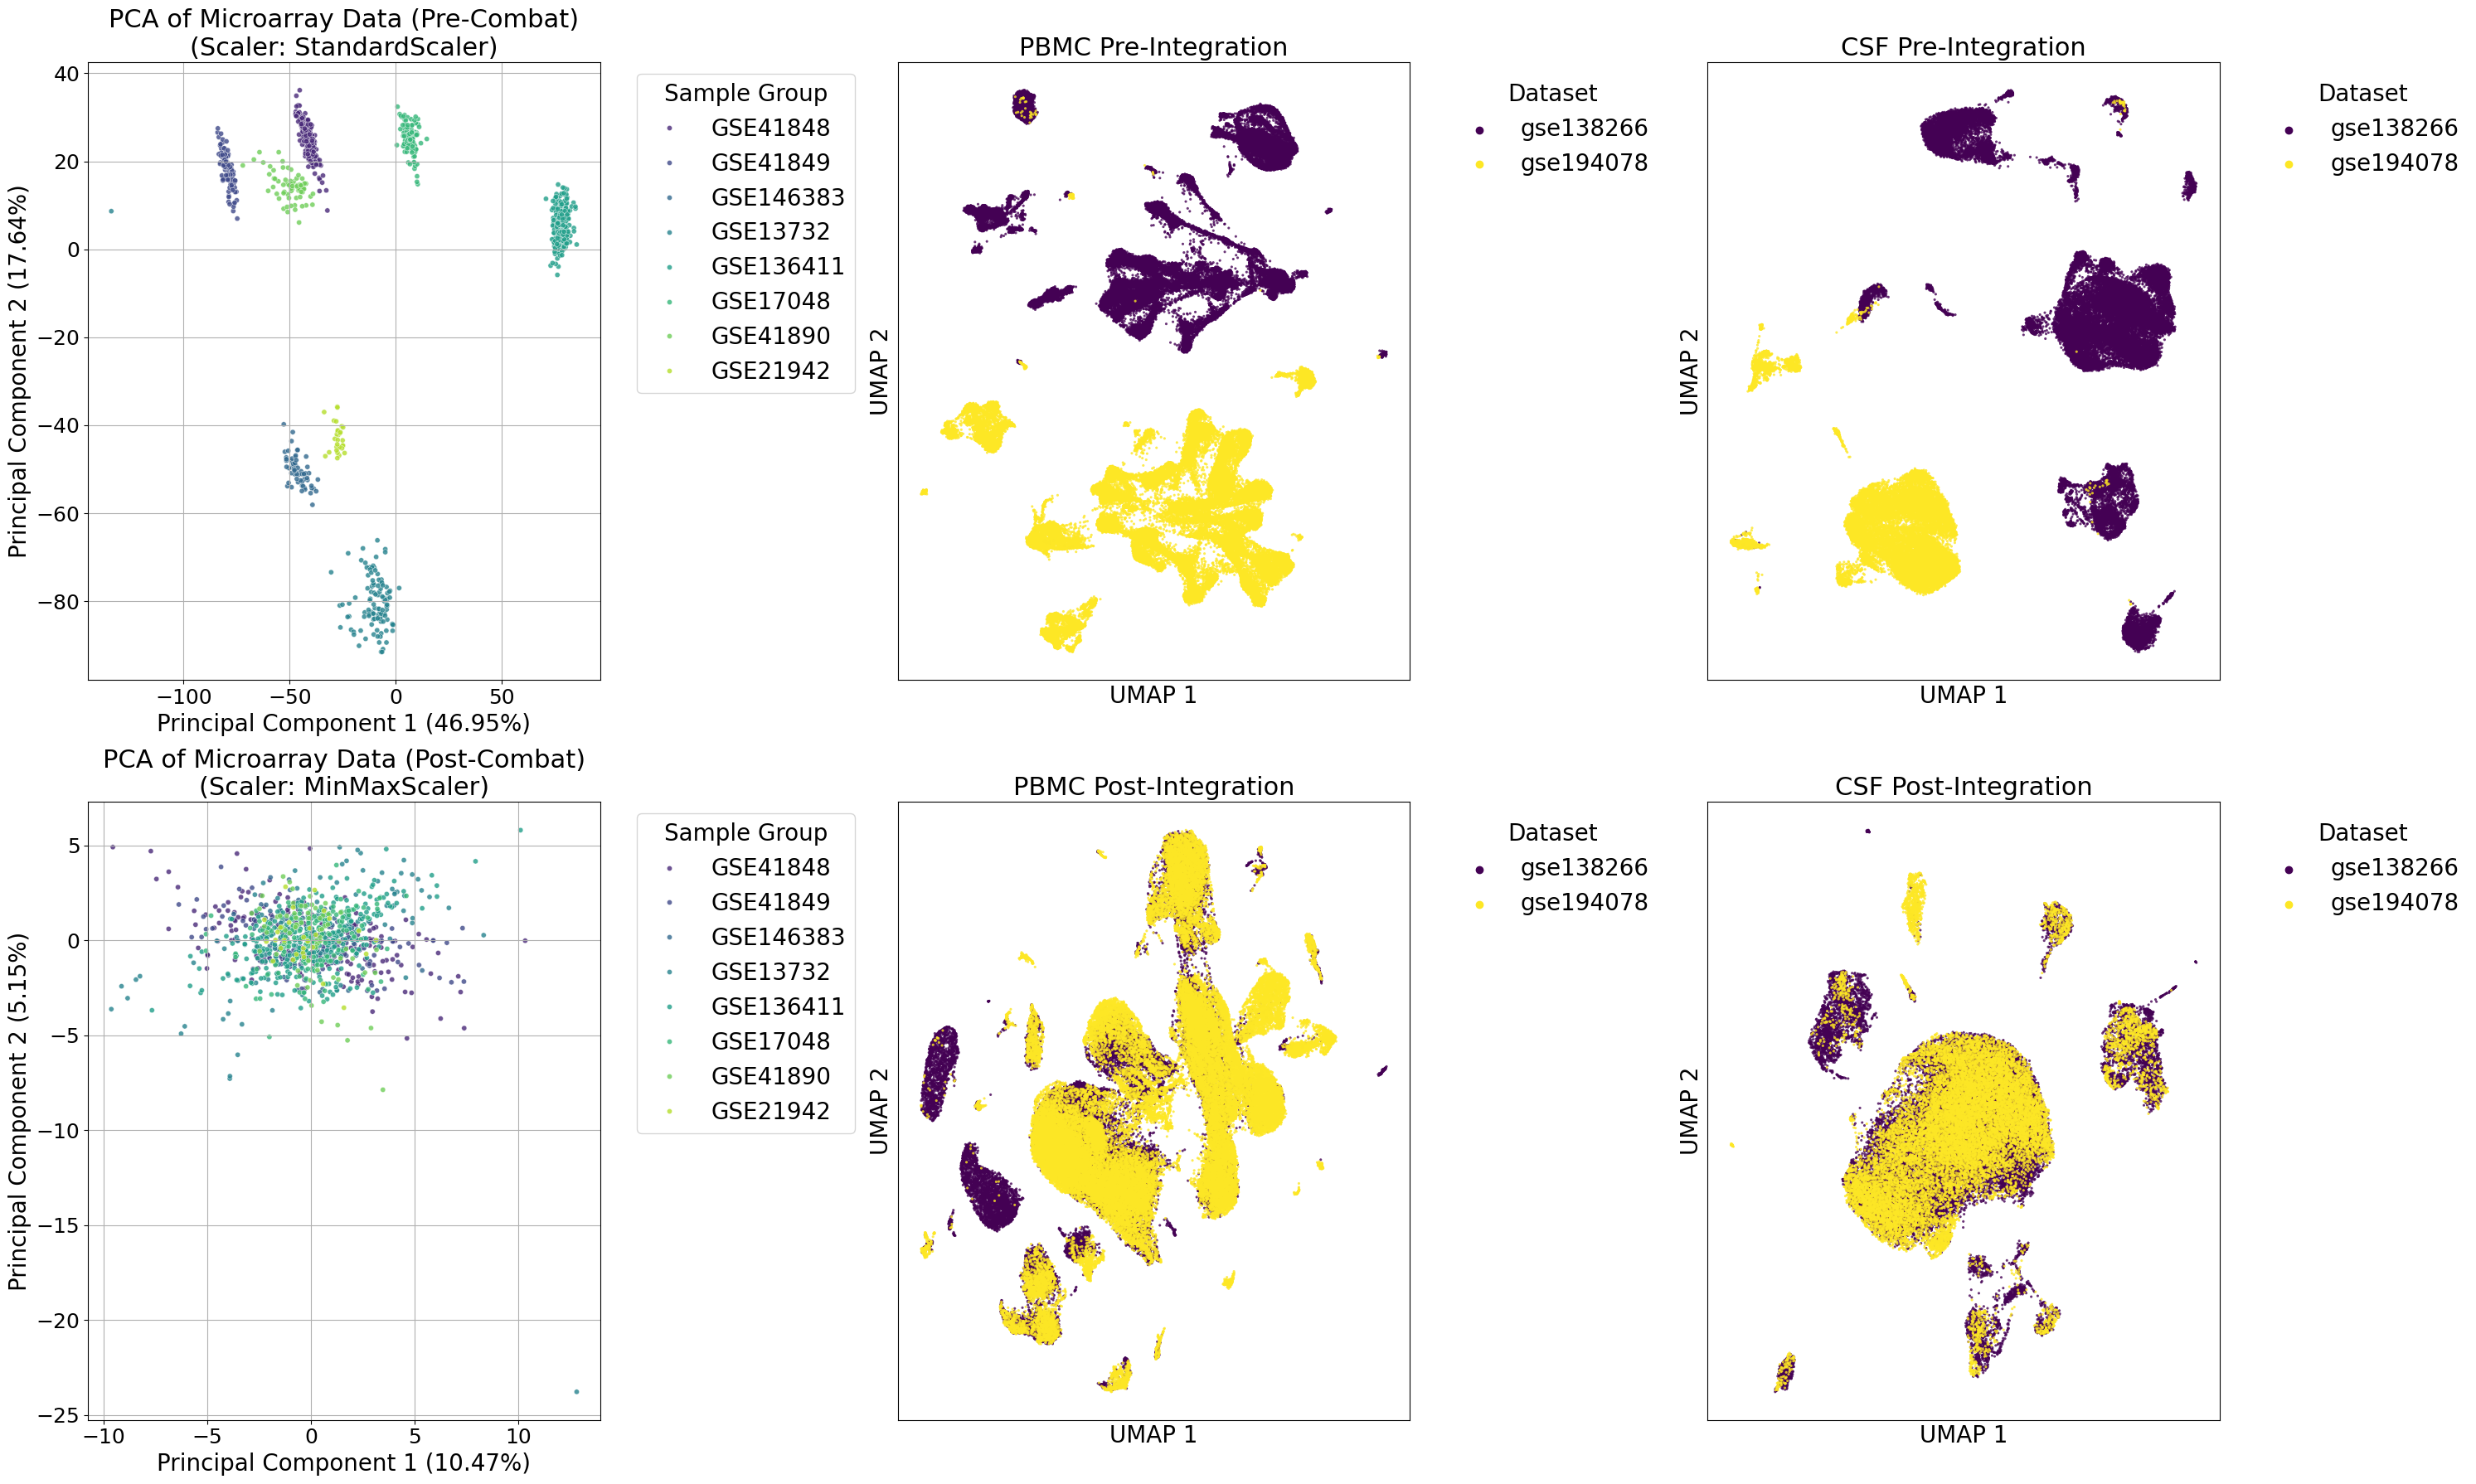

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import anndata as ad
import scanpy as sc
import numpy as np # For creating dummy data
import rapids_singlecell as rsc

classiDataset = ['GSE41848', 'GSE41849', 'GSE146383', 'GSE13732', 'GSE136411', 'GSE17048', 'GSE41890', 'GSE21942']

# Load your data
# Make sure these paths are correct for your environment
microarray_pre = pd.read_csv("../Dataset/microarray/MergedDatasetFull_symbol.csv")
microarray_post = pd.read_csv("../Dataset/microarray/MergedDatasetFullCombat_symbol.csv")

# --- Function to process and plot PCA for a given DataFrame ---
def plot_pca(data, title_suffix, ax, scaler_type='StandardScaler',
             title_fontsize=16, label_fontsize=14, legend_fontsize=12):
    """
    Performs PCA and plots the results for a given DataFrame.

    Args:
        data (pd.DataFrame): The input DataFrame containing 'SampleID', 'Label', and features.
        title_suffix (str): Suffix for the plot title (e.g., '(Pre-Combat)').
        ax (matplotlib.axes.Axes): The axes object to draw the plot on.
        scaler_type (str): Type of scaler to use. Options: 'StandardScaler',
                           'MinMaxScaler', 'RobustScaler', or None (no scaling).
                           Defaults to 'StandardScaler'.
        title_fontsize (int): Font size for the plot title.
        label_fontsize (int): Font size for x and y axis labels.
        legend_fontsize (int): Font size for legend labels.
    """
    data_for_pca = data.copy()

    sample_ids = data_for_pca['SampleID']
    features = data_for_pca.drop(columns=['SampleID', 'Label'])

    # Apply selected scaler
    if scaler_type == 'StandardScaler':
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)
    elif scaler_type == 'MinMaxScaler':
        scaler = MinMaxScaler()
        scaled_features = scaler.fit_transform(features)
    elif scaler_type == 'RobustScaler':
        scaler = RobustScaler()
        scaled_features = scaler.fit_transform(features)
    elif scaler_type is None:
        scaled_features = features.values # Use raw values if no scaling
    else:
        raise ValueError("Invalid scaler_type. Choose from 'StandardScaler', 'MinMaxScaler', 'RobustScaler', or None.")

    pca = PCA(n_components=2, random_state=42)
    principal_components = pca.fit_transform(scaled_features)

    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    group_variable = sample_ids.str.split('-').str[0]
    pca_df['Group'] = group_variable.apply(lambda x: classiDataset[int(x)])

    sns.scatterplot(
        x='PC1',
        y='PC2',
        hue='Group',
        data=pca_df,
        palette='viridis',
        s=20,
        alpha=0.8,
        ax=ax
    )
    ax.set_title(f'PCA of Microarray Data {title_suffix}\n(Scaler: {scaler_type or "None"})',
                 fontsize=title_fontsize)
    ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
                  fontsize=label_fontsize)
    ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
                  fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=label_fontsize - 2) # Slightly smaller ticks
    ax.tick_params(axis='y', labelsize=label_fontsize - 2) # Slightly smaller ticks
    ax.legend(title='Sample Group', bbox_to_anchor=(1.05, 1), loc='upper left',
              fontsize=legend_fontsize, title_fontsize=legend_fontsize)
    ax.grid(True)

# --- Function to process and plot UMAP for a given AnnData object ---
def plot_umap(adata, title, ax, color_by='group',
              title_fontsize=16, label_fontsize=14, legend_fontsize=12):
    """
    Performs UMAP and plots the results for a given AnnData object.
    Assumes necessary preprocessing (normalization, scaling, log, PCA) is already done.

    Args:
        adata (anndata.AnnData): The input AnnData object.
        title (str): Title for the plot.
        ax (matplotlib.axes.Axes): The axes object to draw the plot on.
        color_by (str): The observation (column in .obs) to color the UMAP by.
        title_fontsize (int): Font size for the plot title.
        label_fontsize (int): Font size for x and y axis labels.
        legend_fontsize (int): Font size for legend labels.
    """
    print(adata) # Keep this for debugging if needed

    # Run PCA if not already in .obsm.
    if 'X_pca' not in adata.obsm_keys():
        print(f"Warning: X_pca not found for {title}. Running sc.pp.pca...")
        sc.pp.pca(adata, n_comps=50)

    # Compute neighbors using rapids_singlecell (GPU accelerated)
    if 'neighbors' not in adata.uns_keys():
        print(f"Warning: Neighbors not found for {title}. Running rsc.pp.neighbors...")
        rsc.pp.neighbors(adata, n_neighbors=10, n_pcs=40, use_rep='X_pca')

    # Compute UMAP using rapids_singlecell (GPU accelerated)
    if 'X_umap' not in adata.obsm_keys():
        print(f"Warning: UMAP coordinates not found for {title}. Running rsc.tl.umap...")
        rsc.tl.umap(adata)

    # Plot UMAP using scanpy's plotting function
    # Note: sc.pl.umap itself accepts 'title', 'legend_fontsize', 'frameon'
    # Other font sizes (axis labels, tick labels) need to be set on the 'ax' object
    sc.pl.umap(adata, color=color_by, title=title, ax=ax, show=False,
               palette='viridis', size=20, alpha=0.8,
               legend_fontsize=legend_fontsize # This sets the font size of legend *entries*
               )

    # Set the title font size directly on the axes object
    ax.set_title(title, fontsize=title_fontsize)

    # Set x and y axis labels and their font sizes
    ax.set_xlabel('UMAP 1', fontsize=label_fontsize)
    ax.set_ylabel('UMAP 2', fontsize=label_fontsize)

    # Set tick label font sizes
    ax.tick_params(axis='x', labelsize=label_fontsize - 2)
    ax.tick_params(axis='y', labelsize=label_fontsize - 2)

    # Manually set legend title font size if a legend exists
    legend = ax.get_legend()
    if legend:
        legend.set_title('Sample Group' if color_by == 'group' else color_by.capitalize(),
                         prop={'size': legend_fontsize})
        # Adjust legend position if needed (bbox_to_anchor example)
        legend.set_bbox_to_anchor((1.05, 1)) # Example, adjust as per your layout needs
        legend.set_loc('upper left')

    ax.grid(True)


# IMPORTANT: Replace these dummy AnnData objects with your actual loaded AnnData files!
pbmc_pre = sc.read_h5ad("../Dataset/Integrated/MERGE_PBMC.h5ad")
pbmc_post = sc.read_h5ad("../Dataset/Integrated/PBMC_64BATCHSIZE")
csf_pre = sc.read_h5ad("../Dataset/Integrated/MERGE_CSF.h5ad")
csf_post = sc.read_h5ad("../Dataset/Integrated/CSF_64BATCHSIZE.h5ad")


# --- Create a figure with two rows and three columns ---
# Increased figsize for better clarity with larger labels
fig, axes = plt.subplots(2, 3, figsize=(30, 18))

# Define consistent font sizes for all plots
GLOBAL_TITLE_FONTSIZE = 22
GLOBAL_LABEL_FONTSIZE = 20
GLOBAL_LEGEND_FONTSIZE = 20

# Row 0: All 'Pre' plots
plot_pca(microarray_pre, '(Pre-Combat)', axes[0, 0], scaler_type='StandardScaler',
         title_fontsize=GLOBAL_TITLE_FONTSIZE, label_fontsize=GLOBAL_LABEL_FONTSIZE,
         legend_fontsize=GLOBAL_LEGEND_FONTSIZE)
plot_umap(pbmc_pre, 'PBMC Pre-Integration', axes[0, 1], color_by='dataset',
          title_fontsize=GLOBAL_TITLE_FONTSIZE, label_fontsize=GLOBAL_LABEL_FONTSIZE,
          legend_fontsize=GLOBAL_LEGEND_FONTSIZE)
plot_umap(csf_pre, 'CSF Pre-Integration', axes[0, 2], color_by='dataset',
          title_fontsize=GLOBAL_TITLE_FONTSIZE, label_fontsize=GLOBAL_LABEL_FONTSIZE,
          legend_fontsize=GLOBAL_LEGEND_FONTSIZE)

# Row 1: All 'Post' plots
plot_pca(microarray_post, '(Post-Combat)', axes[1, 0], scaler_type='MinMaxScaler',
         title_fontsize=GLOBAL_TITLE_FONTSIZE, label_fontsize=GLOBAL_LABEL_FONTSIZE,
         legend_fontsize=GLOBAL_LEGEND_FONTSIZE)
plot_umap(pbmc_post, 'PBMC Post-Integration', axes[1, 1], color_by='dataset',
          title_fontsize=GLOBAL_TITLE_FONTSIZE, label_fontsize=GLOBAL_LABEL_FONTSIZE,
          legend_fontsize=GLOBAL_LEGEND_FONTSIZE)
plot_umap(csf_post, 'CSF Post-Integration', axes[1, 2], color_by='dataset',
          title_fontsize=GLOBAL_TITLE_FONTSIZE, label_fontsize=GLOBAL_LABEL_FONTSIZE,
          legend_fontsize=GLOBAL_LEGEND_FONTSIZE)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
unique_csf_cd4 = joblib.load("../ML/Store/CD4_CSF_SAMU/uniqueClusters.pkl")
unique_pbmc_bcells = joblib.load("../ML/Store/PBMC_BCELLS_2DATASET/uniqueClusters.pkl")
unique_csf_bcells = joblib.load("../ML/Store/CSF_BCELLS/uniqueClusters.pkl")
unique_pbmc_cd4 = joblib.load("../ML/Store/PBMC_CD4TNONAIVE_2DATASET/uniqueClusters.pkl")

In [ ]:
def stats_cluster(name, clusters):
    print(name)
    clusters = list(clusters.keys())
    total_lengths = 0
    num_clusters = len(clusters)
    
    for cluster in clusters:
        total_lengths += len(cluster)

    average_length = total_lengths / num_clusters

    print(f"Total number of clusters: {num_clusters}")
    print(f"Sum of all cluster lengths: {total_lengths}")
    print(f"Average length of the clusters: {average_length:.2f}") # Formatted to 2 decimal places

In [ ]:
stats_cluster("csf_cd4", unique_csf_cd4)
stats_cluster("csf_bcells", unique_csf_bcells)
stats_cluster("pbmc_bcells", unique_pbmc_bcells)
stats_cluster("pbmc_cd4", unique_pbmc_cd4)